# Computational Gastronomy — Assignment 1 — Question 3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data")
OUT_DIR = Path("q3_output")
OUT_DIR.mkdir(exist_ok=True)

BLUE = "#2a78d6"

# (Recipe ID, Ingredient Name) format for the table
pairs = pd.read_csv(DATA_DIR / "recipe_id_ingredient_name.csv")
print("Loaded", len(pairs), "(recipe_id, ingredient_name) rows covering",
      pairs["recipe_id"].nunique(), "recipes")
pairs.head()

Loaded 97427 (recipe_id, ingredient_name) rows covering 9999 recipes


,recipe_id,ingredient_name
0,1,eggs
1,1,milk
2,1,self-raising flour
3,1,powder
4,1,caster sugar


## Q3(a) — Frequency-rank distribution

In [ ]:
ingredient_freq = pairs["ingredient_name"].value_counts()

ranks = np.arange(1, len(ingredient_freq) + 1)
frequencies = ingredient_freq.values

total_occurrences = frequencies.sum()
normalized_frequencies = frequencies / total_occurrences

print(f"{len(ingredient_freq)} unique ingredients, {total_occurrences} total ingredient occurrences")
print(f"rank 1 (most frequent): {ingredient_freq.index[0]!r} "
      f"with {frequencies[0]} occurrences (normalized freq = {normalized_frequencies[0]:.5f})")
print(f"rank {len(ingredient_freq)} (least frequent): {ingredient_freq.index[-1]!r} "
      f"with {frequencies[-1]} occurrence(s) (normalized freq = {normalized_frequencies[-1]:.7f})")

13226 unique ingredients, 97427 total ingredient occurrences
rank 1 (most frequent): 'olive oil' with 2734 occurrences (normalized freq = 0.02806)
rank 13226 (least frequent): 'red ipa' with 1 occurrence(s) (normalized freq = 0.0000103)


Saved -> q3_output/q3a_frequency_rank_distribution.png
Saved -> q3_output/q3a_frequency_rank_distribution.svg


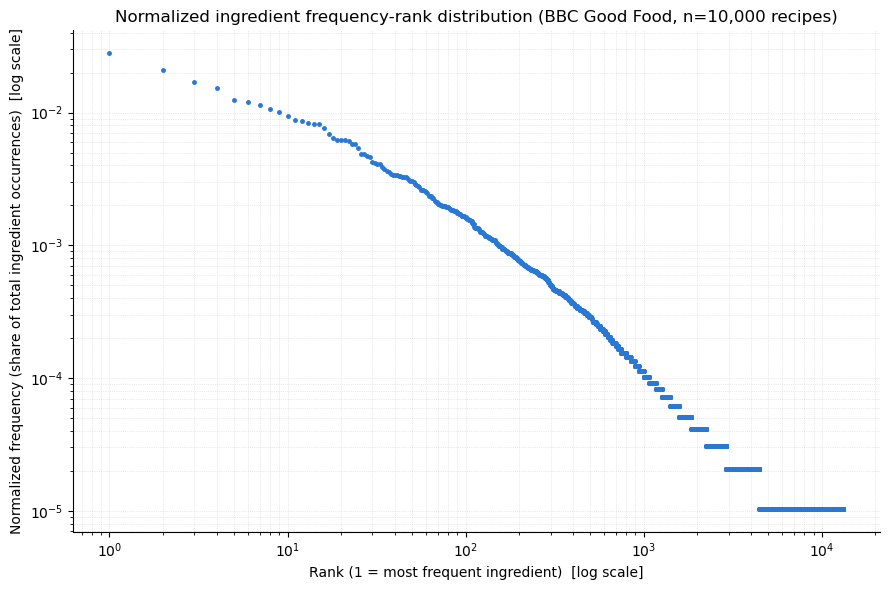

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(ranks, normalized_frequencies, marker="o", markersize=2.5, linestyle="none", color=BLUE)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Normalized ingredient frequency-rank distribution (BBC Good Food, n=10,000 recipes)")
ax.set_xlabel("Rank (1 = most frequent ingredient)  [log scale]")
ax.set_ylabel("Normalized frequency (share of total ingredient occurrences)  [log scale]")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.5)
fig.tight_layout()

png_path = OUT_DIR / "q3a_frequency_rank_distribution.png"
svg_path = OUT_DIR / "q3a_frequency_rank_distribution.svg"
fig.savefig(png_path, dpi=150)
fig.savefig(svg_path)
print(f"Saved -> {png_path}")
print(f"Saved -> {svg_path}")
plt.show()

In [ ]:
# table used for plotting the graph
rank_table = pd.DataFrame({
    "rank": ranks,
    "ingredient_name": ingredient_freq.index,
    "frequency": frequencies,
    "normalized_frequency": normalized_frequencies,
})
table_path = OUT_DIR / "q3a_frequency_rank_table.csv"
rank_table.to_csv(table_path, index=False)
print(f"Saved -> {table_path}")
rank_table.head(10)

Saved -> q3_output/q3a_frequency_rank_table.csv


,rank,ingredient_name,frequency,normalized_frequency
0,1,olive oil,2734,0.028062
1,2,butter,2046,0.021000
2,3,flour,1670,0.017141
3,4,eggs,1497,0.015365
4,5,garlic,1213,0.012450
5,6,onion,1178,0.012091
6,7,caster sugar,1103,0.011321
7,8,milk,1032,0.010593
8,9,golden caster sugar,993,0.010192
9,10,garlic clove,917,0.009412
